<h1 align="center">Computación de Alto Desempeño</h1>
<h1 align="center">Ecuación de Calor 1D</h1>
<h1 align="center">2024</h1>
<h1 align="center">MEDELLÍN - COLOMBIA </h1>

***
|[![Outlook](https://img.shields.io/badge/Microsoft_Outlook-0078D4?style=plastic&logo=microsoft-outlook&logoColor=white)](mailto:calvarezh@udemedellin.edu.co)||[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/carlosalvarezh/HPC/blob/main/HPC17_EcuacionCalor.ipynb)
|-:|:-|--:|
|[![LinkedIn](https://img.shields.io/badge/linkedin-%230077B5.svg?style=plastic&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/carlosalvarez5/)|[![@alvarezhenao](https://img.shields.io/twitter/url/https/twitter.com/alvarezhenao.svg?style=social&label=Follow%20%40alvarezhenao)](https://twitter.com/alvarezhenao)|[![@carlosalvarezh](https://img.shields.io/badge/github-%23121011.svg?style=plastic&logo=github&logoColor=white)](https://github.com/carlosalvarezh)|

<table>
 <tr align=left><td><img align=left src="https://github.com/carlosalvarezh/Curso_CEC_EAFIT/blob/main/images/CCLogoColorPop1.gif?raw=true" width="25">
 <td>Text provided under a Creative Commons Attribution license, CC-BY. All code is made available under the FSF-approved MIT license.(c) Carlos Alberto Alvarez Henao</td>
</table>

***

# **Resolviendo la Ecuación Unidimensional del Calor en C con OpenMP**

### **Introducción**

El estudio de cómo el calor se distribuye a lo largo de un material con el paso del tiempo es un problema fundamental en diversas disciplinas de la ciencia y la ingeniería, como la termodinámica, la ciencia de materiales y la física. Este fenómeno puede modelarse mediante la **ecuación del calor**, una ecuación diferencial parcial (EDP) que describe la variación de temperatura en un medio a medida que el calor se transfiere dentro de él.

En este proyecto, vamos a enfocarnos en resolver la **ecuación del calor en una dimensión** (1D), que simula cómo el calor se propaga en una barra o alambre a lo largo de su longitud. Para ello, utilizaremos el **método explícito de diferencias finitas**, que discretiza tanto el espacio como el tiempo, permitiendo obtener soluciones numéricas aproximadas. Este enfoque es adecuado para estudiantes, ya que permite abordar de manera intuitiva el proceso de discretización y solución numérica de ecuaciones diferenciales.

Adicionalmente, aprovecharemos la capacidad de **paralelización con OpenMP** en C, lo que permitirá optimizar la velocidad de cálculo en simulaciones de gran escala, dividiendo el trabajo entre múltiples núcleos de procesamiento. Esto es crucial para resolver problemas numéricos de manera eficiente en escenarios con grandes cantidades de datos o con requisitos de tiempo de ejecución estrictos.

El objetivo de este ejercicio es que los estudiantes puedan implementar una solución eficiente en C para este problema clásico, comprendiendo no solo los conceptos matemáticos detrás de la ecuación del calor, sino también las estrategias de optimización y paralelización que se pueden aplicar en la computación de alto rendimiento.

### **Contexto histórico**

La ecuación del calor fue formulada por primera vez en 1822 por el matemático francés **Jean Baptiste Joseph Fourier**, en su obra *"Théorie analytique de la chaleur"* (Teoría Analítica del Calor). El trabajo de Fourier no solo estableció las bases para el estudio de la transferencia de calor, sino que también dio origen a las **series de Fourier**, una herramienta matemática fundamental utilizada para descomponer funciones complejas en componentes sinusoidales más simples. Este concepto es esencial para el análisis y la solución de muchos problemas en física e ingeniería.

## **Planteamiento del Problema y solución analítica**

La **ecuación del calor en una dimensión** describe cómo la temperatura cambia a lo largo de una barra conforme el calor se dispersa en ella. Esta ecuación se expresa como:

$$
\frac{\partial u(x,t)}{\partial t} = \alpha \frac{\partial^2 u(x,t)}{\partial x^2}
$$

donde:
- $ u(x,t) $ es la temperatura en la posición $ x $ y tiempo $ t $,
- $ \alpha $ es la **difusividad térmica**, que mide qué tan rápido se propaga el calor en el material.

**Condiciones de Contorno**

Consideremos una barra de longitud $ L $ donde los extremos de la barra están a **temperatura cero** en todo momento. Esto significa que el calor no puede acumularse en los extremos, es decir:

$$
u(0,t) = u(L,t) = 0 \quad \text{para todo} \ t \geq 0
$$

**Condición Inicial**

Para la temperatura inicial en la barra, vamos a suponer una distribución simple: 

$$
u(x, 0) = \sin\left(\frac{\pi x}{L}\right)
$$

Esto significa que la temperatura inicial sigue una forma de onda sinusoidal a lo largo de la barra.

**Solución Cerrada**

Para este caso particular, donde la condición inicial es una función sinusoidal y los extremos de la barra están fijos en cero, la **solución analítica** de la ecuación del calor es:

$$
u(x,t) = \sin\left(\frac{\pi x}{L}\right) e^{-\frac{\pi^2 \alpha}{L^2} t}
$$

**Explicación:**

1. **Parte espacial**: La función $ \sin\left(\frac{\pi x}{L}\right) $ describe cómo la temperatura está distribuida a lo largo de la barra en el inicio. En los extremos ($ x = 0 $ y $ x = L $), la función es cero, cumpliendo con las condiciones de contorno.

2. **Parte temporal**: El término $ e^{-\frac{\pi^2 \alpha}{L^2} t} $ muestra cómo la temperatura en cada punto de la barra disminuye con el tiempo. A medida que el tiempo pasa, este factor exponencial disminuye, haciendo que la temperatura se reduzca gradualmente hasta que la barra se enfría completamente.


## **Solución numérica**

La **ecuación del calor** es una ecuación diferencial parcial (EDP) que modela cómo el calor se distribuye en un medio a lo largo del tiempo. En una dimensión, esta ecuación describe cómo la temperatura en cada punto de un material cambia debido a la transferencia de calor con sus puntos vecinos.

En su forma más básica, la ecuación del calor en una dimensión se expresa como:

$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}
$$

Donde:
- $ u(x,t) $ es la temperatura en la posición $ x $ y el tiempo $ t $,
- $ \alpha $ es la **difusividad térmica** del material, una constante positiva que mide la rapidez con la que el calor se dispersa en el material.

Esta ecuación permite predecir cómo varía la temperatura a lo largo de un cuerpo cuando está sometido a un proceso de transferencia de calor. Tiene aplicaciones clave en múltiples áreas como la ingeniería térmica, la física de materiales e incluso en la simulación de entornos virtuales y videojuegos, donde la correcta simulación del calor es fundamental para representar fenómenos físicos de manera realista.

En este ejercicio, nuestro objetivo es resolver esta ecuación de manera numérica utilizando el **Método de Diferencias Finitas (FDM)** en el lenguaje C, optimizando el cálculo mediante paralelización con **OpenMP** para mejorar el rendimiento en simulaciones de gran escala.

#### **Conceptos básicos del Método de Diferencias Finitas**

El **Método de Diferencias Finitas (FDM)** es una técnica numérica utilizada para aproximar las soluciones de ecuaciones diferenciales parciales como la ecuación del calor. La idea principal detrás del FDM es discretizar el dominio continuo del problema (en este caso, la barra o el material donde se transfiere el calor) en puntos discretos. Así, en lugar de resolver directamente la ecuación con derivadas continuas, aproximamos las derivadas mediante diferencias entre los valores en esos puntos.

#### **Discretización Espacial y Temporal**

En la ecuación del calor, necesitamos aproximar tanto las derivadas espaciales como las temporales. A continuación, se muestra cómo se discretizan estas derivadas:

1. **Derivada espacial**: La segunda derivada con respecto a $ x $ se puede aproximar usando diferencias centrales entre puntos vecinos. Matemáticamente, esto se representa como:

$$
\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}
$$

Donde $ \Delta x $ es el tamaño del paso espacial, $ u_{i+1} $, $ u_i $ y $ u_{i-1} $ son los valores de la temperatura en los puntos $ i+1 $, $ i $ e $ i-1 $, respectivamente.

2. **Derivada temporal**: La derivada con respecto al tiempo se aproxima utilizando diferencias hacia adelante:

$$
\frac{\partial u}{\partial t} \approx \frac{u^{n+1}_i - u^n_i}{\Delta t}
$$

Donde $ \Delta t $ es el tamaño del paso de tiempo, $ u^{n+1}_i $ es la temperatura en el punto $ i $ en el tiempo $ t_{n+1} $, y $ u^n_i $ es la temperatura en el tiempo $ t_n $.

#### **Ecuación de Actualización**

Al combinar estas dos aproximaciones, obtenemos la **ecuación de actualización explícita** para la ecuación del calor:

$$
u^{n+1}_i = u^n_i + \alpha \frac{\Delta t}{\Delta x^2} \left( u^n_{i+1} - 2u^n_i + u^n_{i-1} \right)
$$

Esta ecuación nos permite calcular la temperatura en un punto $ i $ en el siguiente paso de tiempo $ n+1 $, en función de las temperaturas actuales de los puntos vecinos ($ i+1 $ e $ i-1 $) y la temperatura en el punto $ i $ en el tiempo presente $ n $.

**Clave para los estudiantes**: La implementación del Método de Diferencias Finitas se basa en aplicar iterativamente esta ecuación para todos los puntos espaciales de interés, actualizando la temperatura en cada paso temporal.

### **Estabilidad Numérica**

Una de las principales consideraciones al utilizar el método explícito de diferencias finitas es la **estabilidad numérica**. Para que la simulación sea precisa y no diverja, es crucial que los parámetros de discretización (es decir, los valores de $ \Delta t $ y $ \Delta x $) satisfagan una condición de estabilidad.

La **condición de estabilidad** para el método explícito de diferencias finitas en la ecuación del calor se expresa como:

$$
\text{Coef} = \frac{\alpha \Delta t}{\Delta x^2} \leq \frac{1}{2}
$$

Esta fórmula define una relación directa entre la difusividad térmica $ \alpha $, el tamaño del paso de tiempo $ \Delta t $ y el tamaño del paso espacial $ \Delta x $. Si el valor de $ \text{Coef} $ es mayor que 0.5, la solución numérica se vuelve inestable, generando oscilaciones erráticas y resultados incorrectos.

## **Enunciado del Trabajo Escrito**

#### **Objetivo:**

El objetivo de este trabajo es que los estudiantes desarrollen un código en **C** que resuelva numéricamente la ecuación de calor en una dimensión utilizando el **Método de Diferencias Finitas**. Además, el código deberá estar paralelizado utilizando **OpenMP** para mejorar el rendimiento en términos de tiempo de ejecución. Los estudiantes deberán comparar la solución numérica con la solución analítica para diferentes tamaños de $ h $ (paso espacial), y reportar las métricas de rendimiento del código utilizando varias configuraciones de hilos.

#### **Tareas a realizar:**

1. **Implementación numérica con paralelización:**
   - Desarrollar un programa en **C** que resuelva la ecuación de calor en una dimensión utilizando el **Método de Diferencias Finitas (FDM)**.
   - Utilizar **OpenMP** para paralelizar el cálculo en la etapa de iteración temporal y espacial.
   - Asegurarse de que la paralelización sea eficiente y que se distribuya el trabajo de manera adecuada entre los hilos disponibles.

2. **Comparación de la solución numérica y la solución analítica:**
   - Comparar los resultados numéricos obtenidos con la **solución analítica** de la ecuación del calor para una barra de longitud $ L $ con extremos a temperatura cero y una condición inicial sinusoidal:
     $$
     u(x,t) = \sin\left(\frac{\pi x}{L}\right) e^{-\frac{\pi^2 \alpha}{L^2} t}
     $$
   - Realizar la comparación para al menos **tres valores diferentes de $ h $** (por ejemplo, $ h = 0.1 $, $ h = 0.05 $, $ h = 0.01 $) y medir el error numérico con respecto a la solución analítica.

3. **Métricas de rendimiento:**
   - **Medir el tiempo de ejecución** del programa para diferentes configuraciones de hilos utilizando OpenMP (por ejemplo, 1 hilo, 2 hilos, 4 hilos, 8 hilos).
   - Reportar el **speedup** y la **eficiencia** obtenidos al variar el número de hilos:
     $$
     \text{Speedup} = \frac{\text{Tiempo con un hilo}}{\text{Tiempo con $ n $ hilos}}
     $$
     $$
     \text{Eficiencia} = \frac{\text{Speedup}}{\text{Número de hilos}}
     $$
   - Evaluar cómo cambia el rendimiento y la precisión cuando se varían los tamaños de $ h $.

4. **Visualización de los resultados:**
   - Crear gráficos que comparen la **solución numérica** con la **solución analítica** para los diferentes valores de $ h $ utilizados.
   - Presentar gráficas de **tiempo de ejecución**, **speedup** y **eficiencia** para los diferentes números de hilos probados.
   - Mostrar visualmente el error entre la solución numérica y la solución analítica en función del paso espacial $ h $.

#### **Contenido del Informe:**

El informe escrito deberá incluir las siguientes secciones:

1. **Introducción**:
   - Explicar brevemente la ecuación del calor en 1D y la relevancia del problema.
   - Describir el objetivo del trabajo, destacando la implementación del método de diferencias finitas y la paralelización con OpenMP.

2. **Implementación del código**:
   - Explicar detalladamente el algoritmo utilizado para resolver la ecuación del calor numéricamente.
   - Describir cómo se realizó la paralelización con OpenMP, indicando las secciones del código que fueron paralelizadas y justificando su elección.

3. **Resultados numéricos**:
   - Comparar los resultados numéricos con la solución analítica.
   - Incluir gráficos que muestren la solución numérica y la analítica en diferentes puntos temporales para los distintos valores de $ h $.
   - Mostrar gráficamente la evolución del error entre ambas soluciones a lo largo del tiempo.

4. **Análisis del rendimiento**:
   - Presentar una tabla con los **tiempos de ejecución** para diferentes números de hilos.
   - Incluir gráficos del **speedup** y la **eficiencia** conforme se incrementa el número de hilos.
   - Discutir las limitaciones observadas y las mejoras logradas mediante la paralelización.

5. **Conclusiones**:
   - Resumir los principales hallazgos del trabajo en términos de precisión numérica y rendimiento.
   - Reflexionar sobre las ventajas y desventajas del uso de OpenMP para la paralelización de este tipo de problemas.
   - Proponer posibles mejoras en el código o enfoques alternativos para incrementar la eficiencia o precisión.


### **Recomendaciones:**

- Utiliza **`omp_get_wtime()`** para medir el tiempo de ejecución de las secciones paralelizadas del código.
- Asegúrate de probar tu código en diferentes configuraciones de hilos y tamaños de $ h $ para obtener resultados variados.
- Compara tu solución numérica con la analítica utilizando **normas de error**, por ejemplo, el **error absoluto** o el **error relativo**.
- La claridad y calidad de las gráficas y el análisis de resultados será un factor importante en la evaluación.

### **Criterios de Evaluación:**

- **Correcta implementación** del algoritmo numérico y su paralelización con OpenMP.
- **Precisión** en la comparación entre la solución numérica y la analítica.
- **Análisis detallado** de las métricas de rendimiento, incluyendo tiempos de ejecución, speedup y eficiencia.
- **Calidad del informe**, tanto en redacción como en la presentación gráfica de resultados.

## **Solución serial**

1. **Definición de constantes**:
   ```c
   #define L 1.0  // Longitud de la barra
   #define alpha 0.01  // Difusividad térmica
   #define T_max 0.5  // Tiempo máximo de simulación
   #define N_x 100  // Número de puntos espaciales
   #define N_t 1000  // Número de pasos de tiempo
   ```
   Aquí se definen las constantes del problema:
   - $ L $: longitud de la barra.
   - $ \alpha $: difusividad térmica del material.
   - $ T_{\text{max}} $: tiempo máximo de simulación.
   - $ N_x $: número de puntos espaciales (discretización de la barra).
   - $ N_t $: número de pasos de tiempo.

2. **Inicialización de la condición inicial**:
   ```c
   void inicializar_condicion_inicial(double* u, int N_x, double dx) {
       for (int i = 0; i < N_x; i++) {
           double x = i * dx;
           u[i] = sin(M_PI * x / L);  // Condición inicial: onda sinusoidal
       }
   }
   ```
   Esta función establece la **condición inicial** del problema. En este caso, se usa una función sinusoidal que describe la temperatura inicial a lo largo de la barra.

3. **Aplicación de las condiciones de frontera**:
   ```c
   void aplicar_condiciones_frontera(double* u) {
       u[0] = 0.0;  // Extremo izquierdo a 0°C
       u[N_x - 1] = 0.0;  // Extremo derecho a 0°C
   }
   ```
   Esta función garantiza que los extremos de la barra siempre estén a temperatura cero durante la simulación.

4. **Cálculo de la solución numérica**:
   ```c
   void resolver_ecuacion_calor(double* u, double* u_nueva, int N_x, int N_t, double dx, double dt) {
       double coef = alpha * dt / (dx * dx);
       for (int t = 0; t < N_t; t++) {
           for (int i = 1; i < N_x - 1; i++) {
               u_nueva[i] = u[i] + coef * (u[i+1] - 2 * u[i] + u[i-1]);
           }
           aplicar_condiciones_frontera(u_nueva);
           memcpy(u, u_nueva, N_x * sizeof(double));
       }
   }
   ```
   Esta es la **función principal** que resuelve la ecuación del calor usando el método de diferencias finitas. El ciclo interno realiza el cálculo de las nuevas temperaturas en cada punto de la barra. Después de calcular las nuevas temperaturas, se aplican las condiciones de frontera y se actualizan los valores de la temperatura para el siguiente paso.

5. **Función principal `main`**:
   ```c
   int main() {
       double dx = L / (N_x - 1);  // Tamaño del paso espacial
       double dt = T_max / N_t;  // Tamaño del paso temporal
       double* u = (double*) malloc(N_x * sizeof(double));
       double* u_nueva = (double*) malloc(N_x * sizeof(double));
       inicializar_condicion_inicial(u, N_x, dx);
       aplicar_condiciones_frontera(u);
       resolver_ecuacion_calor(u, u_nueva, N_x, N_t, dx, dt);
       for (int i = 0; i < N_x; i++) {
           double x = i * dx;
           printf("u(%f) = %f\n", x, u[i]);
       }
       free(u);
       free(u_nueva);
       return 0;
   }
   ```
   Esta es la función principal que configura el problema. Inicializa los arreglos de temperatura, calcula los tamaños de los pasos espaciales y temporales, y luego llama a las funciones necesarias para resolver la ecuación del calor. Finalmente, imprime los resultados y libera la memoria.

### **Código Serial (C)**

In [ ]:
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <string.h> 

// Parámetros de la ecuación del calor
#define L 1.0  // Longitud de la barra
#define alpha 0.01  // Difusividad térmica
#define T_max 0.5  // Tiempo máximo de simulación
#define N_x 100  // Número de puntos espaciales
#define N_t 1000  // Número de pasos de tiempo

// Función para inicializar la condición inicial
void inicializar_condicion_inicial(double* u, int N_x, double dx) {
    for (int i = 0; i < N_x; i++) {
        double x = i * dx;
        u[i] = sin(M_PI * x / L);  // Condición inicial: onda sinusoidal
    }
}

// Función para aplicar la condición de frontera
void aplicar_condiciones_frontera(double* u) {
    u[0] = 0.0;  // Extremo izquierdo a 0°C
    u[N_x - 1] = 0.0;  // Extremo derecho a 0°C
}

// Función principal que resuelve la ecuación del calor en 1D (versión serial)
void resolver_ecuacion_calor(double* u, double* u_nueva, int N_x, int N_t, double dx, double dt) {
    // Coeficiente de estabilidad (Coeficiente de la fórmula)
    double coef = alpha * dt / (dx * dx);

    // Iteración temporal (bucle sobre t)
    for (int t = 0; t < N_t; t++) {
        // Iteración espacial (bucle sobre x)
        for (int i = 1; i < N_x - 1; i++) {
            // Diferencias finitas para calcular u en el siguiente paso temporal
            u_nueva[i] = u[i] + coef * (u[i+1] - 2 * u[i] + u[i-1]);
        }

        // Aplicar condiciones de frontera
        aplicar_condiciones_frontera(u_nueva);

        // Copiar la solución nueva en la antigua para el siguiente paso
        memcpy(u, u_nueva, N_x * sizeof(double));
    }
}

// Función principal
int main() {
    // Definir las variables necesarias
    double dx = L / (N_x - 1);  // Tamaño del paso espacial
    double dt = T_max / N_t;  // Tamaño del paso temporal

    // Crear dos arrays: uno para la solución actual y otro para la solución nueva
    double* u = (double*) malloc(N_x * sizeof(double));
    double* u_nueva = (double*) malloc(N_x * sizeof(double));

    // Inicializar la condición inicial (t=0)
    inicializar_condicion_inicial(u, N_x, dx);

    // Aplicar las condiciones de frontera en el tiempo t=0
    aplicar_condiciones_frontera(u);

    // Resolver la ecuación del calor
    resolver_ecuacion_calor(u, u_nueva, N_x, N_t, dx, dt);

    // Mostrar los resultados finales (temperatura en cada punto al final del tiempo)
    printf("Resultados de la simulación al tiempo T = %f:\n", T_max);
    for (int i = 0; i < N_x; i++) {
        double x = i * dx;
        printf("u(%f) = %f\n", x, u[i]);
    }

    // Liberar la memoria dinámica
    free(u);
    free(u_nueva);

    return 0;
}


### **Código Serial (Python)**

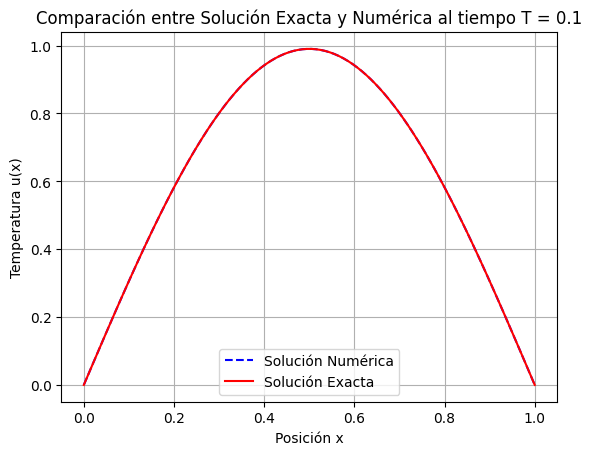

Error absoluto medio: 4.5602914153421685e-07


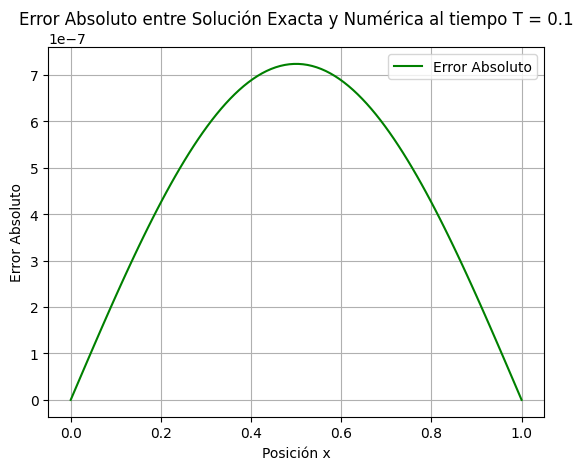

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del problema
L = 1.0  # Longitud de la barra
alpha = 0.01  # Difusividad térmica
T_max = 0.1  # Tiempo máximo de simulación
N_x = 100  # Número de puntos espaciales
N_t = 500  # Número de pasos de tiempo

# Definir el tamaño de los pasos espaciales y temporales
dx = L / (N_x - 1)  # Paso espacial
dt = T_max / N_t  # Paso temporal

# Función para la solución exacta
def solucion_exacta(x, t, L, alpha):
    return np.sin(np.pi * x / L) * np.exp(-alpha * (np.pi**2 / L**2) * t)

# Inicialización de la condición inicial (solución numérica)
def inicializar_condicion_inicial(N_x, dx):
    u = np.zeros(N_x)
    for i in range(N_x):
        x = i * dx
        u[i] = np.sin(np.pi * x / L)  # Condición inicial: onda sinusoidal
    return u

# Función para aplicar las condiciones de frontera (solución numérica)
def aplicar_condiciones_frontera(u):
    u[0] = 0.0  # Extremo izquierdo a 0°C
    u[-1] = 0.0  # Extremo derecho a 0°C

# Función principal que resuelve la ecuación del calor en 1D (solución numérica)
def resolver_ecuacion_calor(u, N_x, N_t, dx, dt, alpha):
    coef = alpha * dt / (dx * dx)
    
    u_nueva = np.copy(u)  # Inicializamos la nueva solución
    for t in range(N_t):
        # Iteración espacial
        for i in range(1, N_x - 1):
            u_nueva[i] = u[i] + coef * (u[i + 1] - 2 * u[i] + u[i - 1])

        # Aplicar las condiciones de frontera
        aplicar_condiciones_frontera(u_nueva)

        # Actualizar u para el siguiente paso temporal
        u[:] = u_nueva[:]
    
    return u

# Función principal
def main():
    # Inicializar la condición inicial (solución numérica)
    u_numerica = inicializar_condicion_inicial(N_x, dx)

    # Aplicar las condiciones de frontera en t=0
    aplicar_condiciones_frontera(u_numerica)

    # Resolver la ecuación del calor numéricamente
    u_final = resolver_ecuacion_calor(u_numerica, N_x, N_t, dx, dt, alpha)

    # Obtener la solución exacta para el tiempo final
    x_vals = np.linspace(0, L, N_x)
    u_exacta = solucion_exacta(x_vals, T_max, L, alpha)

    # Graficar la solución numérica vs solución exacta
    plt.plot(x_vals, u_final, label='Solución Numérica', linestyle='--', color='b')
    plt.plot(x_vals, u_exacta, label='Solución Exacta', linestyle='-', color='r')
    plt.xlabel('Posición x')
    plt.ylabel('Temperatura u(x)')
    plt.title(f'Comparación entre Solución Exacta y Numérica al tiempo T = {T_max}')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Calcular y mostrar el error absoluto medio
    error_abs = np.abs(u_final - u_exacta)
    print(f"Error absoluto medio: {np.mean(error_abs)}")

    # Graficar el error absoluto entre ambas soluciones
    plt.plot(x_vals, error_abs, label='Error Absoluto', color='g')
    plt.xlabel('Posición x')
    plt.ylabel('Error Absoluto')
    plt.title(f'Error Absoluto entre Solución Exacta y Numérica al tiempo T = {T_max}')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()


## **Solución paralela**

In [ ]:
# implemente la solución paralela en C y usando OpenMP

## **Bonus track: Implementación 2D**